# CMI and Markov length for ring of Fibonacci plaquettes

Calculating CMI with density matrices 

\begin{equation}

CMI = I(A:C|B) = S(AB) + S(BC) - S(ABC) - S(B),

\end{equation}

where $S(Q)$ is the von Neumann entropy of the $Q$ subsystem:

\begin{equation}

S(Q) = - tr ( \rho_{Q} \log \rho_Q ),

\end{equation}

with

\begin{equation}

\rho_{Q} = tr_{\bar{Q}} (\rho).

\end{equation}

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import math
from functools import reduce
import scienceplots
from itertools import combinations
from collections import Counter
from collections.abc import Iterable

In general, for a row of $k$ Fibonacci plaquettes, the ground state is given by:
\begin{equation}
    \ket{\text{g.s.}}=\frac{1}{D^k}\sum_{i=0}^k\phi^i\left(\sum \frac{1}{\phi^{a}} \frac{1}{(\sqrt{\phi})^{b}}\text{ states with $i$ applied plaquettes}  \right),
\end{equation}
where $a$ is the number of unflipped (black) inner edges and $b$ is the number of flipped (red) inner edges. The ground state is normalized by the factor $D$ (raised to the power of the total number of plaquettes), which is given by:
\begin{equation}
    D = \sqrt{1+\phi},
\end{equation}
and the factor of $\phi$ is the golden ratio:
\begin{equation}
    \phi = \frac{1+\sqrt{5}}{2}.
\end{equation}

A plaquette operator is composed out a product of four Pauli $X$ operators acting on its edges. However, because of the non-trivial fusion rule of Fibonacci anyons:
\begin{equation}
    \tau \times \tau = 1+ \tau,
\end{equation}
an edge that is shared between two plaquette operators will be in superposition of flipped and unflipped bits, with different weights specified in detail by Fibonacci fusion category.

In [2]:
# ============================================================
# Fibonacci code parameters
# ============================================================

# -------------------------
# Golden ratio
# -------------------------
phi = (1+ np.sqrt(5))/2
D = np.sqrt(1+phi**2)

# -------------------------
# Combinatorial helper
# -------------------------
def sublists(k: int, m: int) -> list[list[int]]:
    """
    Return all sublists of length m from [1, 2, ..., k].
    """
    if m < 0 or m > k:
        return []

    return [list(c) for c in combinations(range(1, k + 1), m)]



In [20]:
# -------------------------
# Function finding repeated integers in the total list of edges
# -------------------------
def find_repeated_integers(obj):
    """
    Recursively searches a possibly multidimensional object
    and returns a list of integers that appear more than once.
    """

    def flatten(x):
        if isinstance(x, int):
            yield x
        elif isinstance(x, Iterable) and not isinstance(x, (str, bytes)):
            for item in x:
                yield from flatten(item)

    numbers = list(flatten(obj))
    counts = Counter(numbers)

    return [num for num, count in counts.items() if count > 1]

# -------------------------
# Function generating all subarrays of the given array
# -------------------------

def all_subarrays(arr):
    result = []

    for start in range(len(arr)):
        for end in range(start + 1, len(arr) + 1):
            result.append(arr[start:end])

    return result


In [21]:
# ============================================================
# Defining function computing rho_0
# ============================================================

# -------------------------
# Tensor product helper
# -------------------------
def kron_power(v, N):
    """Compute v ⊗ v ⊗ ... ⊗ v (N times)"""
    return reduce(np.kron, [v] * N)

# -------------------------
# Basis states |0> and |1>
# -------------------------
ket_0 = np.array([1.0, 0.0])
ket_1 = np.array([0.0, 1.0])

# -------------------------
# Pauli Matrices and Identity
# -------------------------

#Pauli Matrices
Pauli_X= np.array([[0.0, 1.0],[1.0, 0.0]])
Pauli_Z= np.array([[1.0, 0.0],[0.0, -1.0]])

# identity matrix 
I = np.eye(2)

# -------------------------
# #Defining local operator
# -------------------------
def local_operator(op, i, N):
    """
    Build operator acting on i-th qubit (0-based index) in N-qubit system.
    """
    ops = [I] * N
    ops[i] = op
    return reduce(np.kron, ops)


# -------------------------
# #Defining plaquette operator
# -------------------------
def plaquette_operator(i1,i2,i3,i4,N):
    """
    A = XXXX
    """
    return local_operator(Pauli_X, i1, N) @ local_operator(Pauli_X, i2, N) @ local_operator(Pauli_X, i3, N) @ local_operator(Pauli_X, i4, N)


# -------------------------
# Functions computing the gound state and rho_0 given the system size and plaquettes' edges
# -------------------------
def ground_state(N, plaquettes, number_plaquettes,D=D,phi=phi):
    """
    Function generating Fibonacci plaquettes' ground state
    N - total number of qubits 
    plaquettes - array of lists of plaquette indices
    number_plaquettes - total number of plaquettes
    D - total quantum dimension
    phi - golden ratio
    """
    ket_0N = kron_power(ket_0, N)
    ket_gs = ket_0N.copy()
    
    #Selecing number of plaquettes to apply from 1 to number_plaquettes
    for k in range(1,number_plaquettes+1):
        if k ==1:
            #Generating all possible sublists of k plaquette indices out of number_plaquettes
            plaquette_combinations = sublists(number_plaquettes, k)
            #accessing a sublist (given plaquette combination)
            for m in plaquette_combinations:
                #accessing elements of sublist
                for h in m:
                    p = plaquettes[h-1]
                    a = plaquette_operator(*p, N)
                    config = phi * a@ket_0N
                    ket_gs += config
        else:
            #Generating all possible sublists of k plaquette indices out of number_plaquettes
            plaquette_combinations = sublists(number_plaquettes, k)
            #accessing a sublist (given plaquette combination)
            for m in plaquette_combinations:
                #Checking for overlaping edges in the given plaquette combination
                
                #List for storing edges
                total_edges_list = []

                #iterating over elements of sublist to create total list of edges
                for h in m:
                    total_edges_list.append(plaquettes[h-1])
                
                #Getting an array of repeated elements in the total list of edges
                inner_edges = find_repeated_integers(total_edges_list)

                #No overlapping edges of multiple plaquettes
                if inner_edges == []:
                    config = ket_0N
                    #Repeated application of plaquette operator 
                    for h in m:
                        p = plaquettes[h-1]
                        a = plaquette_operator(*p, N)
                        config = phi * a@config
                    ket_gs += config
                
                #Case when we have some overlapping edges
                else:
                    #Toric code like terms (inner edges will cancel)
                    config = ket_0N
                    #Repeated application of plaquette operator 
                    for h in m:
                        p = plaquettes[h-1]
                        a = plaquette_operator(*p, N)
                        config = phi * a@config
                    ket_gs += (1/phi)**len(inner_edges) * config


                    #Extra terms coming from Fibonacci fusion rules
                    inner_edges_combinations = all_subarrays(inner_edges)
                    for edge_list in inner_edges_combinations:

                        config = ket_0N

                        #Repeated application of plaquette operator 
                        for h in m:
                            p = plaquettes[h-1]
                            a = plaquette_operator(*p, N)
                            config = phi * a@config

                        #Application of adidtional local X operators on the inner edges in the edge list
                        for edge in edge_list:
                            a = local_operator(Pauli_X, edge, N)
                            config = a@config 
                    
                        ket_gs += (1/(np.sqrt(phi)))**(len(edge_list)) * (1/phi)**(len(inner_edges) - len(edge_list)) * config


    return 1/(D**number_plaquettes) * ket_gs 

def rho_0_function(N, plaquettes, number_plaquettes, D=D, phi=phi):
    ket_gs_fib = ground_state(N, plaquettes, number_plaquettes, D, phi)
    ket_gs_fib = ket_gs_fib / np.linalg.norm(ket_gs_fib)
    return np.outer(ket_gs_fib, ket_gs_fib.conj())

In [22]:
plaquettes_4 = [
        (0, 1, 2, 3),
        (3, 4, 5, 6),
        (6, 7, 8, 9),
        (9, 10, 11, 0),
    ]

In [6]:
#test 
test = ground_state(12, plaquettes_4, 4,D=D,phi=phi)
print(test)
print(np.count_nonzero(test))

[1.50266446e+15 0.00000000e+00 0.00000000e+00 ... 0.00000000e+00
 0.00000000e+00 1.50290009e+15]
256


In [23]:
rho_0 = rho_0_function(12, plaquettes_4, 4,D=D,phi=phi)
print(rho_0)
print("Density matrix shape:", rho_0.shape)
print("Number of non-zero entries:", np.count_nonzero(rho_0))

[[0.00645052 0.         0.         ... 0.         0.         0.01688768]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.01688768 0.         0.         ... 0.         0.         0.04421251]]
Density matrix shape: (4096, 4096)
Number of non-zero entries: 1764


Subsequantly, we define the noise channel:

\begin{equation}

\mathcal{E}^i_p(\cdot) = (1-p)(\cdot) + pZ_i(\cdot)Z_i

\end{equation}

acting on qubits that are shared between plaquettes. For example, for 12-qubit system with 4 plaquettes, the noise will act on sites $[0,3,6,9]$.

In [24]:
# ============================================================
# Code to compute density matrix after noise channel application
# ============================================================

# -------------------------
# Defining the phase flip channel
# -------------------------
def phase_flip_channel(rho, p, i, N):
    """ 
    Function implementing the application of the noise channel on qubit i. 
    Returns the matrix rho_p_i after the application of the noise on one qubit
    i - qubit number
    p - noise rate 
    N - total system size
    rho - total density matrix
    """
    Z_i = local_operator(Pauli_Z, i, N)
    return (1 - p) * rho + p * (Z_i @ rho @ Z_i)

# -------------------------
# Repeated application of phase flip chanell -> noise channel
# -------------------------
def noise_channel(rho_0, p, N, indexlist):
    """ 
    Function implementing the noise channel on qubit all qubits. 
    Returns the matrix rho_p_i after the application of the noise on one qubit
    indexlist - qubits on which the noise is applied
    p - noise rate 
    N - total system size
    rho_0 - initial density matrix
    """
    rho = rho_0
    for i in indexlist:
        rho = phase_flip_channel(rho, p, i, N)
    return rho 

Now, we will define functions to caluclate von Neuman entropies of the whole matrix and the reduced density matrices to subsequently calculate CMI. 

In [25]:
# ============================================================
# Code to compute entropies and CMI for given density matrix
# ============================================================

#Calculating von Neumann entropy
def von_neumann_entropy(rho):
    """
    Compute von Neumann entropy S(rho) = -Tr(rho log rho) = -Sum (lamba log lamba), where lambda's are eigenvalues
    """
    eigvals = np.linalg.eigvalsh(rho)

    # remove zeros safely
    eigvals = eigvals[eigvals > 1e-12]

    S = -np.sum(eigvals * np.log2(eigvals))

    return S


#Function to compute reduced density matrix
def partial_trace(rho, keep, N):
    """
    Partial trace over all qubits not listed in keep.

    rho:
        Full density matrix of shape (2^N, 2^N)

    keep:
        List of qubit indices to keep, using Python 0-based indexing.

    N:
        Total number of qubits.

    Returns:
        Reduced density matrix on the qubits in keep.
    """

    keep = sorted(keep)

    # Qubits to trace out
    trace_out = [q for q in range(N) if q not in keep]

    # Reshape rho into tensor form:
    # rho[i1, i2, ..., iN, j1, j2, ..., jN]
    rho_tensor = rho.reshape([2] * N + [2] * N)

    # Trace out qubits from largest index to smallest.
    # This avoids axis-shifting problems after each trace.
    current_N = N

    for q in sorted(trace_out, reverse=True):
        rho_tensor = np.trace(
            rho_tensor,
            axis1=q,
            axis2=q + current_N,
        )
        current_N -= 1

    dim_keep = 2 ** len(keep)

    return rho_tensor.reshape(dim_keep, dim_keep)


#Function to compute CMI depending on noise rate
def CMI(p,indexlist, rho_0, A, B, C, N):
    """
    Compute I(A:C|B) = S(AB) + S(BC) - S(B) - S(ABC).
    """

    rho = noise_channel(rho_0, p, N,indexlist)

    AB = sorted(A + B)
    BC = sorted(B + C)
    ABC = sorted(A + B + C)

    S_AB = von_neumann_entropy(partial_trace(rho, AB, N))
    S_BC = von_neumann_entropy(partial_trace(rho, BC, N))
    S_B = von_neumann_entropy(partial_trace(rho, B, N))
    S_ABC = von_neumann_entropy(partial_trace(rho, ABC, N))

    return S_AB + S_BC - S_B - S_ABC

The first partition into the regions that we are interested in for 12 qubits is given by:

\begin{align}

&A = [1,2]\\

&B = [3,4,5,5,9,10,11,0]\\

&C = [7,8],

\end{align}

where we considered that some edges will be shared between plaquettes and we don't want to trace theut fully

We considered the indexing of qubits staring from 0 to match the Python syntax. Subsequently, we compute CMI for this region partition.

In [26]:
# ============================================================
# Computation of CMI
# ============================================================

# -------------------------
# Defining regions that will be traced out
# -------------------------

A = [1,2]

B = [3,4,5,6,9,10,11,0]

C = [7,8]

# -------------------------
# List of qubits on which we apply the noise
# -------------------------
indexlist_4 = [0,3,6,9]

# -------------------------
# Computing CMI for different noise rates
# -------------------------

#Array of different noise rates
p_array = np.linspace(0.001,0.999,40)

cmi_array = np.zeros(len(p_array))

for i in range(len(p_array)):
    cmi_array[i] = CMI(p_array[i],indexlist_4,rho_0,A=A,B=B,C=C,N=12)

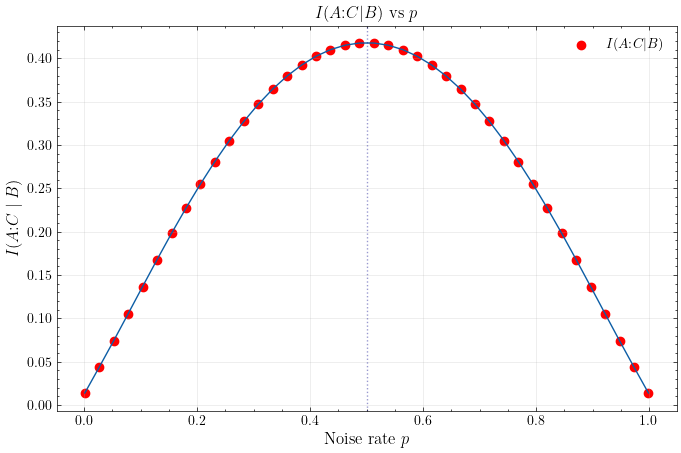

In [27]:
# ============================================================
# Plot of the results of CMI vs noise rate p
# ============================================================


fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(p_array, cmi_array,lw=1)
ax.scatter(p_array, cmi_array,color='red', label=r'$I(A{:}C|B)$')
ax.axvline(0.5, color='darkblue', ls=':', alpha=0.4)
ax.set_xlabel(r'Noise rate $p$', fontsize=12)
ax.set_ylabel(r'$I(A{:}C \mid B)$ ', fontsize=12)
ax.set_title(r' $I(A{:}C|B)$ vs $p$', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.style.use('science')
plt.savefig("New_plots/CMI_vs_p_fib_ring.png", dpi=300)
plt.show()

The results presented above were computed for 12 qubits, with the partition into regions A,B,C given by: $A = [1,2], B = [3,4,5,6,9,10,11,0],$ and $C = [7,8].$ However, to compute Markov length, we need to repeat the calculation above for different system sizes $r$, where $r$ is the number of plaquettes separating region A from region C. For instance, for the calculation above, $r=1$, because region $B$ encloses region $A$ like a one-dimensional ring. 

Subsequently, we know that CMI should satisfy the following bound with finite Markov length $\xi = \xi(p)$ as long as the system stays in one-phase of matter:
\begin{equation}
I(A:C \mid B)
\leq a e^{-r/\xi(p)} + c_0,
\end{equation}
where $a$ is a proportionality constant (for constatnt size of regions $A$ and $C$) and $c_0$ is a vertical offset, signifying the minimal value to which the CMI function will be converging for incresing system sizes (which is shown in the following plots). In particular, for our system, $c_0 =0$, as observed on the plot above. 

Then, it is possible to compute $\xi = \xi(p)$ considering:
\begin{equation}
\ln(I(A:C \mid B)) = -\frac{1}{\xi(p)} + \ln{a},
\end{equation}
Therfore, for each noise rate $p$, we can compute CMI for differnt system sizes $r$, and then compute $\xi$ by fitting a linear function to the logarithm of CMI (minus offset) versus $r$, and taking the negative inverse of the slope. This computation was executed below.

In [28]:
# -------------------------
# Noise rates used to evaluate Markov length
# -------------------------
p_array2 = np.linspace(0.001,0.999,10)

In [29]:
# -------------------------
# Function returning plquette indices for given number of plaquettes
# -------------------------

def get_plaquettes(number_of_plaquettes):
    indices = []
    for n in range(number_of_plaquettes):
        indices.append([(0+3*n)%(number_of_plaquettes*3),(1+3*n)%(number_of_plaquettes*3),(2+3*n)%(number_of_plaquettes*3),(3+3*n)%(number_of_plaquettes*3)])
    return np.array(indices)

print(get_plaquettes(4))

[[ 0  1  2  3]
 [ 3  4  5  6]
 [ 6  7  8  9]
 [ 9 10 11  0]]


In [30]:
# -------------------------
# Function returning error indices for given number of qubits in the system 
# -------------------------

def get_error_index(total_system_size):
    indices = []
    for i in range(total_system_size):
        if i%3 == 0:
            indices.append(i)
    return np.array(indices)

print(get_error_index(12))

[0 3 6 9]


In [ ]:
# ============================================================
# Defining function computing Markov length
# ============================================================

def fit_markov_length_offset(distances, cmi_values, offset=0.0, threshold=1e-12):
    """
    Fit:

        CMI(r) - offset = a exp(-r / xi)

    so:

        log(CMI(r) - offset) = log(a) - r / xi
    """

    distances = np.array(distances)
    cmi_values = np.array(cmi_values)

    shifted = cmi_values - offset

    # Only keep points where log is well-defined
    mask = shifted > threshold

    if np.sum(mask) < 2:
        return np.nan

    x = distances[mask]
    y = np.log(shifted[mask])

    slope, intercept = np.polyfit(x, y, 1)

    if slope >= 0:
        return np.nan

    return -1.0 / slope


# ------------------------------------------------------------
# Define distance-dependent partitions
# ------------------------------------------------------------


# Define maximum distance r
R_max = 2

distances = np.arange(1, R_max + 1)

# ------------------------------------------------------------
# Computing CMI matrix
# ------------------------------------------------------------

cmi_matrix = np.zeros((len(p_array2), len(distances)))

for ip, p in enumerate(p_array2):
    for idd, d in enumerate(distances):

        A_d = list(range(1, 3))
        B_d = list(range(0,1))+ list(range(3, 3+d*3+1)) + list( range(3+d*3+3, 3+d*3+3+d*3))
        C_d = list(range(3+d*3+1, 3+d*3+3))
        system_size = len(A_d+B_d+C_d)

        nb_plaquettes = int(system_size/3)

        rho_0 = rho_0_function(system_size,get_plaquettes(nb_plaquettes),nb_plaquettes,D=D,phi=phi)

        errorindexlist = get_error_index(system_size)

        cmi_matrix[ip, idd] = CMI(
            p,errorindexlist,
            rho_0,
            A=A_d,
            B=B_d,
            C=C_d,
            N = system_size 
        )


# ============================================================
# Running function computing Markov length for every p
# ============================================================
xi_array = np.array([
    fit_markov_length_offset(distances, cmi_matrix[ip], offset=0.0)
    for ip in range(len(p_array2))
])

In [ ]:
# ------------------------------------------------------------
# Printing output of the computation
# ------------------------------------------------------------

print("xi_array:")
print(xi_array)
print("finite xi values:", np.sum(np.isfinite(xi_array)))

In [ ]:
# ============================================================
# Plot xi(p) vs p
# ============================================================

valid = np.isfinite(xi_array)

plt.style.use('science')
plt.figure(figsize=(8, 5))

plt.plot(p_array2,xi_array, marker='o',lw=2)
plt.axvline(0.5, color='darkblue', ls='-', alpha=0.4)
plt.xlabel(r"Noise rate $p$")
plt.ylabel(r"Markov length $\xi (p)$")
plt.title(r"Markov Length from Decay of $I(A:C|B)-1$")
plt.tight_layout()
plt.grid(True)
plt.savefig("New_plots/Xi_vs_p_fib_ring.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# CMI vs noise rate p for different distances r
# ============================================================


plt.style.use('science')
plt.figure(figsize=(8,5))

for r in distances:
    plt.plot(p_array2,cmi_matrix[:, r-1],marker='o',label=fr"$r={r}$")

plt.xlabel("Noise rate $p$")
plt.ylabel(r"$I(A:C|B)$")
plt.title("CMI vs Noise Rate for Different Distances")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("New_plots/CMI_vs_p_differnt_r_fib_ring.png", dpi=300)
plt.show()

In [ ]:
# ============================================================
# CMI vs distance r for different noise rates p
# ============================================================

plt.figure(figsize=(8,6))
plt.style.use('science')


for idx in range(1,10,2):

    plt.plot(distances,cmi_matrix[idx]-1,marker='o',label=fr"$p={p_array2[idx]:.3f}$")

plt.yscale('log')

plt.xlabel("Distance $r$")
plt.ylabel(r"$I(A:C|B)$ -1")
plt.title("Exponential Decay of CMI (without Offset) with Distance")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("New_plots/CMI_decay_with_r_fib_ring.png", dpi=300)
plt.show()